170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 44s 0us/step


c:\Users\kiw60\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Train data: (10000, 32, 32, 3)
Train label: (10000,)
Test data: (2000, 32, 32, 3)
Test label: (2000,)


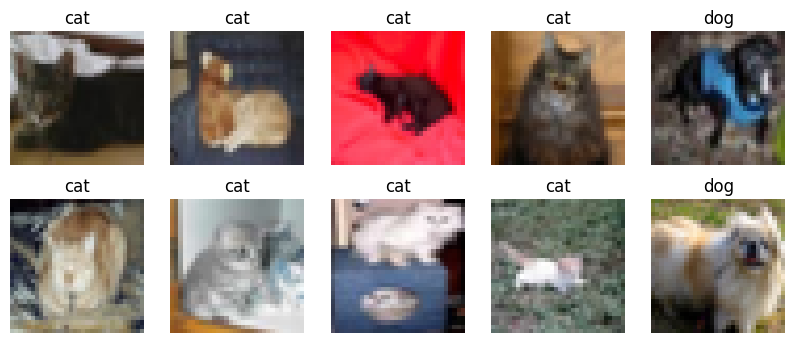

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# =========================
# 1. CIFAR-10 데이터 로드
# =========================

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# CIFAR-10 class index
# airplane: 0
# automobile: 1
# bird: 2
# cat: 3
# deer: 4
# dog: 5
# frog: 6
# horse: 7
# ship: 8
# truck: 9

CAT_LABEL = 3
DOG_LABEL = 5

# =========================
# 2. Cat / Dog 데이터만 선택
# =========================

train_mask = np.where((y_train[:, 0] == CAT_LABEL) | (y_train[:, 0] == DOG_LABEL))[0]
test_mask = np.where((y_test[:, 0] == CAT_LABEL) | (y_test[:, 0] == DOG_LABEL))[0]

x_train_cd = x_train[train_mask]
y_train_cd = y_train[train_mask]

x_test_cd = x_test[test_mask]
y_test_cd = y_test[test_mask]

# =========================
# 3. 라벨 변환
# cat -> 0
# dog -> 1
# =========================

y_train_cd = np.where(y_train_cd[:, 0] == CAT_LABEL, 0, 1)
y_test_cd = np.where(y_test_cd[:, 0] == CAT_LABEL, 0, 1)

# =========================
# 4. 정규화
# =========================

x_train_cd = x_train_cd.astype("float32") / 255.0
x_test_cd = x_test_cd.astype("float32") / 255.0

print("Train data:", x_train_cd.shape)
print("Train label:", y_train_cd.shape)
print("Test data:", x_test_cd.shape)
print("Test label:", y_test_cd.shape)

# =========================
# 5. 데이터 확인
# =========================

class_names = ["cat", "dog"]

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_cd[i])
    plt.title(class_names[y_train_cd[i]])
    plt.axis("off")
plt.show()